# Assignment 3 — Data Science

**Dataset:** Auto MPG (Tabular) + MNIST (Image) + Synthetic Time Series (Sequential)

**Framework:** PyTorch

**Author:** Vahid Hamzeh  
**Student ID:** 402101577

---

## Why PyTorch?

- **Dynamic computation graphs** make debugging much easier compared to TensorFlow's static graph approach.
- **Pythonic API** feels natural and well-suited for research and experimentation.
- **Excellent ecosystem**: torchvision, torchaudio, HuggingFace all natively support PyTorch.
- Widely used in both academia and industry (Meta, Tesla, OpenAI).

## 0. Setup & Imports

In [32]:
import os
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, r2_score, accuracy_score
)

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


---
## 1. Data Preparation — Auto MPG Dataset

**Dual targets:**
1. **Regression:** predict `mpg` (fuel efficiency)
2. **Binary Classification:** predict whether origin == 'usa'

### Why One-Hot Encoding for `origin`?
The `origin` column is a nominal categorical variable (usa / europe / japan). Encoding it as integers (1/2/3) implies a false ordinal relationship. One-Hot Encoding avoids that by creating a separate binary column per category, letting the model learn independent weights for each.

In [33]:
df = sns.load_dataset('mpg')
print("Shape before cleaning:", df.shape)
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape before cleaning: (398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [34]:
df = df.dropna(subset=['horsepower', 'mpg', 'origin'])
print("Shape after cleaning:", df.shape)

y_reg   = df['mpg'].values                           
y_class = (df['origin'] == 'usa').astype(float).values  

num_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
X_num = df[num_features].values

origin_ohe = pd.get_dummies(df['origin'], prefix='origin').values.astype(float)
print("\nOne-Hot Encoded 'origin' columns:", pd.get_dummies(df['origin'], prefix='origin').columns.tolist())

X_full = np.hstack([X_num, origin_ohe])
print(f"\nFeature matrix shape (with OHE): {X_full.shape}")

X = X_full

Shape after cleaning: (392, 9)

One-Hot Encoded 'origin' columns: ['origin_europe', 'origin_japan', 'origin_usa']

Feature matrix shape (with OHE): (392, 9)


In [35]:
X_train_val, X_test, y_class_tv, y_class_test, y_reg_tv, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)
X_train, X_val, y_class_train, y_class_val, y_reg_train, y_reg_val = train_test_split(
    X_train_val, y_class_tv, y_reg_tv, test_size=0.2, random_state=42, stratify=y_class_tv
)

scaler = StandardScaler()
X_train[:, :6] = scaler.fit_transform(X_train[:, :6])   
X_val[:, :6]   = scaler.transform(X_val[:, :6])
X_test[:, :6]  = scaler.transform(X_test[:, :6])

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Class balance (train): {y_class_train.mean():.2f} (fraction USA)")

Train: (250, 9), Val: (63, 9), Test: (79, 9)
Class balance (train): 0.63 (fraction USA)


## 2. PyTorch Dataset & DataLoader

In [36]:
class VehicleDataset(Dataset):
    def __init__(self, X, y_class, y_reg):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y_class = torch.tensor(y_class, dtype=torch.float32)
        self.y_reg   = torch.tensor(y_reg,   dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_class[idx], self.y_reg[idx]

train_dataset = VehicleDataset(X_train, y_class_train, y_reg_train)
val_dataset   = VehicleDataset(X_val,   y_class_val,   y_reg_val)
test_dataset  = VehicleDataset(X_test,  y_class_test,  y_reg_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

---
## 3. Part 1: Multilayer Perceptron (MLP)

### 3.1 Flexible MLP with Batch Normalization

**Why Batch Normalization?**  
BatchNorm normalises each mini-batch's activations to zero mean/unit variance, then applies learnable scale (γ) and shift (β).  
Benefits:
- Reduces internal covariate shift → faster convergence  
- Acts as mild regularizer → reduces need for large Dropout  
- Allows higher learning rates  
- Placed **after** the linear layer and **before** the activation (standard practice)

In [37]:
class FlexibleMLP(nn.Module):
    """
    Configurable MLP supporting:
      - Variable depth (hidden_layers list)
      - Any activation function
      - Optional Dropout
      - Optional Batch Normalization
      - Flexible weight initialisation
    """
    def __init__(self, input_dim, hidden_layers, output_dim,
                 activation_fn=nn.ReLU, dropout_rate=0.0,
                 use_batchnorm=True, init_method='he'):
        super(FlexibleMLP, self).__init__()

        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_layers:
            linear = nn.Linear(current_dim, hidden_dim)
            if init_method == 'he':
                nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')
            elif init_method == 'xavier':
                nn.init.xavier_normal_(linear.weight)
            elif init_method == 'random':
                nn.init.normal_(linear.weight, 0, 0.01)

            layers.append(linear)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim)) 
            layers.append(activation_fn())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### 3.2 Training Loop — with per-epoch metric tracking

**Improvement over baseline:** we now track **accuracy** (classification) and **R²** (regression) at every epoch — not just loss — giving a clearer picture of overfitting/underfitting as training progresses.

In [38]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                epochs, task='regression', scheduler=None, early_stop_patience=None):
    """
    Returns dict with lists: train_loss, val_loss, train_metric, val_metric
    Metric = R² for regression, Accuracy for classification.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_metric': [], 'val_metric': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        t_loss, t_preds, t_targets = 0.0, [], []

        for batch_X, batch_y_class, batch_y_reg in train_loader:
            batch_X = batch_X.to(device)
            targets = (batch_y_reg if task == 'regression' else batch_y_class).to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            t_loss += loss.item() * batch_X.size(0)
            t_preds.extend(outputs.detach().cpu().numpy())
            t_targets.extend(targets.detach().cpu().numpy())

        t_loss /= len(train_loader.dataset)
        history['train_loss'].append(t_loss)

        t_preds = np.array(t_preds).flatten()
        t_targets = np.array(t_targets).flatten()
        if task == 'regression':
            history['train_metric'].append(r2_score(t_targets, t_preds))
        else:
            history['train_metric'].append(accuracy_score(t_targets, (t_preds > 0).astype(float)))

        model.eval()
        v_loss, v_preds, v_targets = 0.0, [], []

        with torch.no_grad():
            for batch_X, batch_y_class, batch_y_reg in val_loader:
                batch_X = batch_X.to(device)
                targets = (batch_y_reg if task == 'regression' else batch_y_class).to(device).unsqueeze(1)
                outputs = model(batch_X)
                loss = criterion(outputs, targets)
                v_loss += loss.item() * batch_X.size(0)
                v_preds.extend(outputs.cpu().numpy())
                v_targets.extend(targets.cpu().numpy())

        v_loss /= len(val_loader.dataset)
        history['val_loss'].append(v_loss)

        v_preds = np.array(v_preds).flatten()
        v_targets = np.array(v_targets).flatten()
        if task == 'regression':
            history['val_metric'].append(r2_score(v_targets, v_preds))
        else:
            history['val_metric'].append(accuracy_score(v_targets, (v_preds > 0).astype(float)))

        if scheduler:
            scheduler.step(v_loss)

        if early_stop_patience:
            if v_loss < best_val_loss:
                best_val_loss = v_loss
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    return history


def evaluate_model(model, loader, task='regression'):
    model.eval()
    all_targets, all_preds = [], []
    with torch.no_grad():
        for batch_X, batch_y_class, batch_y_reg in loader:
            batch_X = batch_X.to(device)
            targets = batch_y_reg.numpy() if task == 'regression' else batch_y_class.numpy()
            outputs = model(batch_X).cpu().numpy().flatten()
            preds = outputs if task == 'regression' else (outputs > 0).astype(float)
            all_targets.extend(targets)
            all_preds.extend(preds)
    return np.array(all_targets), np.array(all_preds)

### 3.3 Plotly Interactive Curve Helper

In [39]:
def plot_curves(histories: dict, title='Training Curves', metric_label='Metric'):
    """
    histories: {experiment_name: history_dict}
    Each history_dict has keys: train_loss, val_loss, train_metric, val_metric
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for name, h in histories.items():
        ax1.plot(h['val_loss'],   label=name)
        ax2.plot(h['val_metric'], label=name)

    ax1.set_title('Validation Loss');   ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax2.set_title(f'Validation {metric_label}'); ax2.set_xlabel('Epoch'); ax2.set_ylabel(metric_label)
    ax1.legend(fontsize=8, loc='upper right')
    ax2.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()


def plot_single_history(history, title='Training Curves', metric_label='Metric'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.plot(history['train_loss'], label='Train Loss',   linewidth=2)
    ax1.plot(history['val_loss'],   label='Val Loss',     linewidth=2, linestyle='--')
    ax1.set_title('Loss (Train vs Val)'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history['train_metric'], label=f'Train {metric_label}', linewidth=2)
    ax2.plot(history['val_metric'],   label=f'Val {metric_label}',   linewidth=2, linestyle='--')
    ax2.set_title(f'{metric_label} (Train vs Val)'); ax2.set_xlabel('Epoch'); ax2.set_ylabel(metric_label)
    ax2.legend()

    plt.tight_layout()
    plt.show()

### 3.4 Baseline MLP — Regression & Classification

In [40]:
input_dim = X_train.shape[1]  

reg_model = FlexibleMLP(input_dim, [64, 32], 1,
                        activation_fn=nn.ReLU, dropout_rate=0.0,
                        use_batchnorm=True, init_method='he').to(device)
reg_criterion = nn.MSELoss()
reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.001)
reg_history = train_model(reg_model, train_loader, val_loader,
                          reg_criterion, reg_optimizer, epochs=50, task='regression')

class_model = FlexibleMLP(input_dim, [64, 32], 1,
                          activation_fn=nn.ReLU, dropout_rate=0.0,
                          use_batchnorm=True, init_method='he').to(device)
class_criterion = nn.BCEWithLogitsLoss()
class_optimizer = optim.Adam(class_model.parameters(), lr=0.001)
class_history = train_model(class_model, train_loader, val_loader,
                            class_criterion, class_optimizer, epochs=50, task='classification')

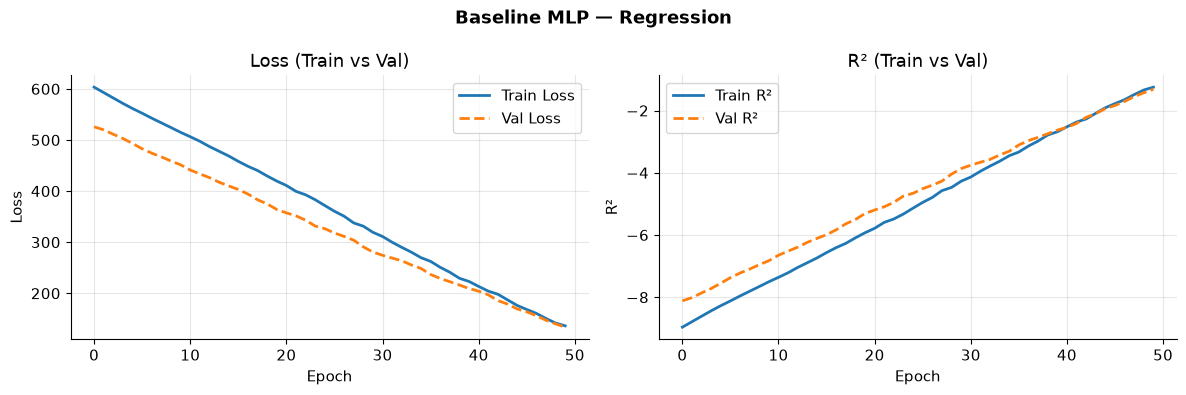

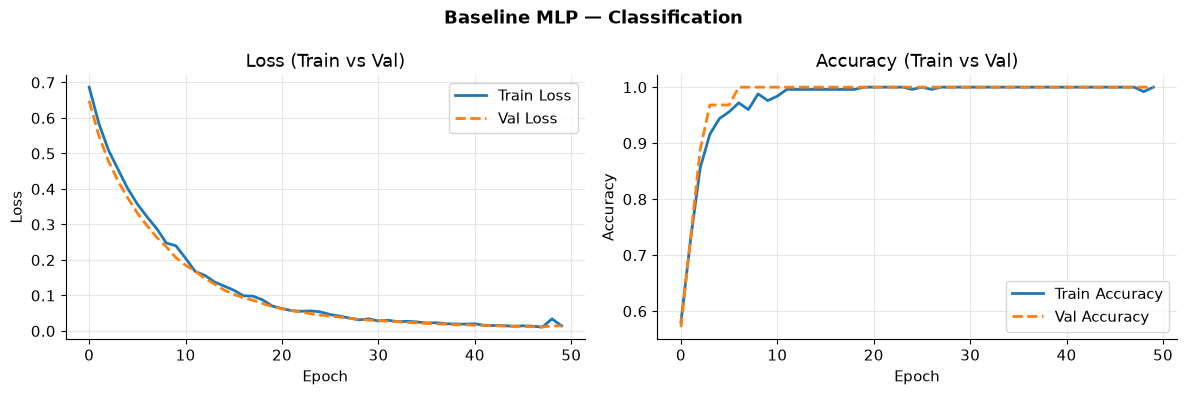

Regression Test Metrics
  MSE:  137.6313
  R²:   -1.2611

Classification Test Metrics
              precision    recall  f1-score   support

     Non-USA       1.00      1.00      1.00        30
         USA       1.00      1.00      1.00        49

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



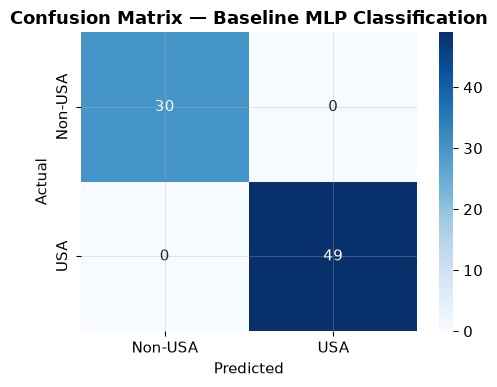

In [41]:
plot_single_history(reg_history,   title='Baseline MLP — Regression',     metric_label='R²')
plot_single_history(class_history, title='Baseline MLP — Classification', metric_label='Accuracy')

y_true_reg,   y_pred_reg   = evaluate_model(reg_model,   test_loader, 'regression')
y_true_class, y_pred_class = evaluate_model(class_model, test_loader, 'classification')

print("Regression Test Metrics")
print(f"  MSE:  {mean_squared_error(y_true_reg, y_pred_reg):.4f}")
print(f"  R²:   {r2_score(y_true_reg, y_pred_reg):.4f}")

print("\nClassification Test Metrics")
print(classification_report(y_true_class, y_pred_class, target_names=['Non-USA', 'USA']))

cm = confusion_matrix(y_true_class, y_pred_class)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-USA', 'USA'], yticklabels=['Non-USA', 'USA'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Baseline MLP Classification', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3.B Network Tuning & Experiments

### B1. Optimisers & Learning Rate

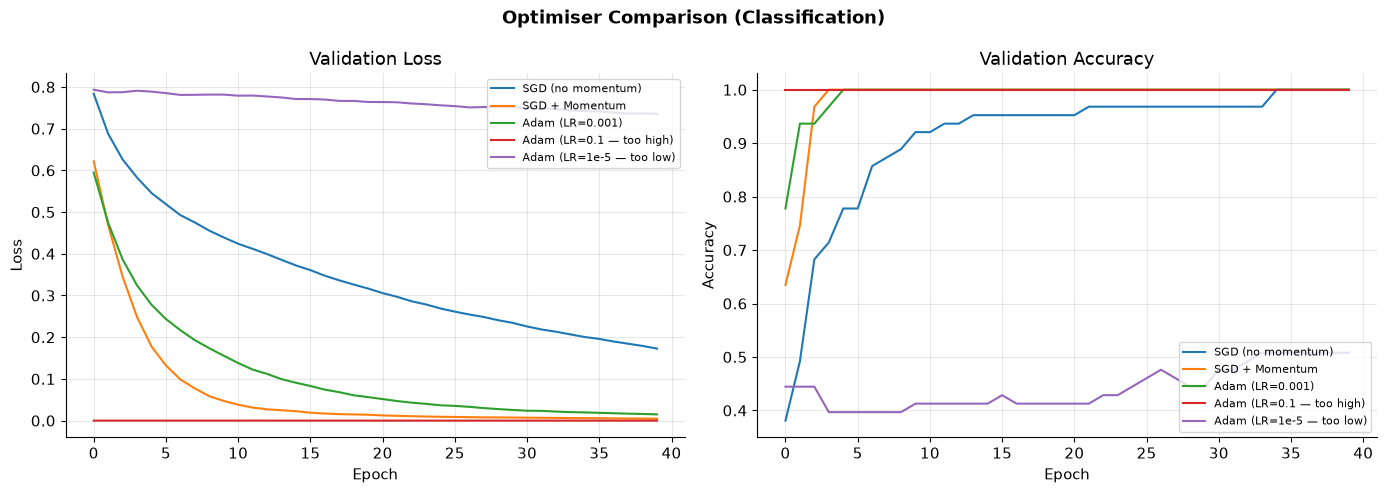

In [42]:
optimizer_configs = {
    'SGD (no momentum)':        lambda p: optim.SGD(p, lr=0.01),
    'SGD + Momentum':           lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
    'Adam (LR=0.001)':          lambda p: optim.Adam(p, lr=0.001),
    'Adam (LR=0.1 — too high)': lambda p: optim.Adam(p, lr=0.1),
    'Adam (LR=1e-5 — too low)': lambda p: optim.Adam(p, lr=1e-5),
}

opt_histories = {}
for name, opt_fn in optimizer_configs.items():
    m = FlexibleMLP(input_dim, [64, 32], 1, nn.ReLU, 0.0, True, 'he').to(device)
    h = train_model(m, train_loader, val_loader,
                    nn.BCEWithLogitsLoss(), opt_fn(m.parameters()),
                    epochs=40, task='classification')
    opt_histories[name] = h

plot_curves(opt_histories, 'Optimiser Comparison (Classification)', 'Accuracy')


**Analysis:**  
- `Adam (LR=0.001)` converges fastest and most stably.  
- `SGD` without momentum converges much slower.  
- `SGD + Momentum` is noticeably better than plain SGD.  
- `LR=0.1` causes severe oscillations — the large gradient steps overshoot the minimum.  
- `LR=1e-5` barely moves — 40 epochs are not enough to converge.

### B1b. Learning Rate Scheduling & Early Stopping

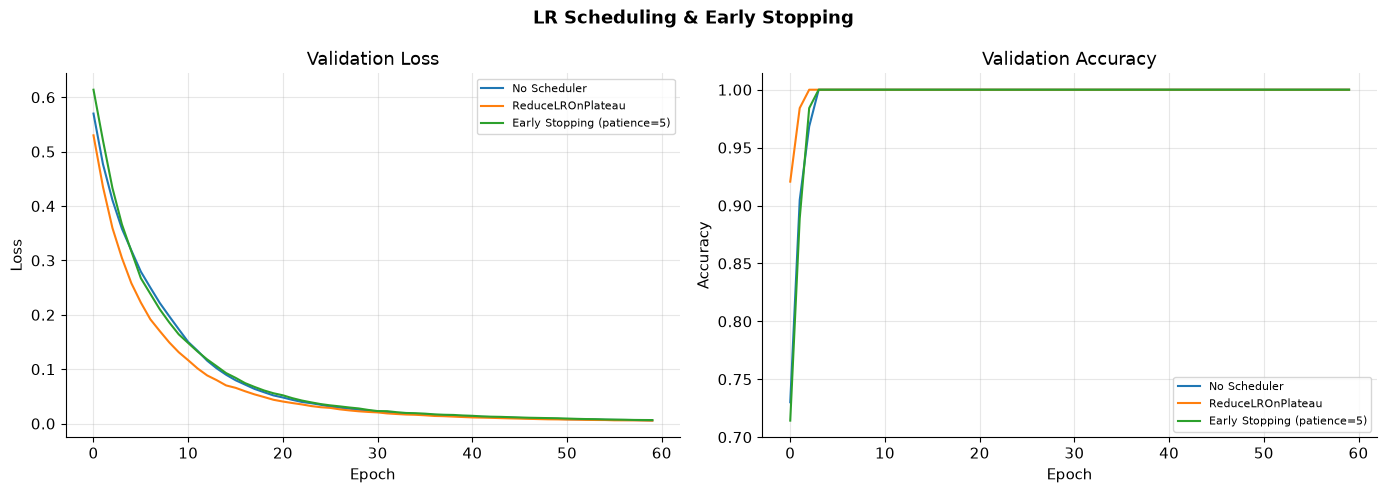

In [43]:
sched_configs = {
    'No Scheduler':                (None,       None),
    'ReduceLROnPlateau':           ('plateau',  None),
    'Early Stopping (patience=5)': (None,       5),
}

sched_histories = {}
for name, (sched_type, patience) in sched_configs.items():
    m   = FlexibleMLP(input_dim, [64, 32], 1, nn.ReLU, 0.0, True, 'he').to(device)
    opt = optim.Adam(m.parameters(), lr=0.001)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5) if sched_type == 'plateau' else None
    h = train_model(m, train_loader, val_loader,
                    nn.BCEWithLogitsLoss(), opt,
                    epochs=60, task='classification',
                    scheduler=sched, early_stop_patience=patience)
    sched_histories[name] = h

plot_curves(sched_histories, 'LR Scheduling & Early Stopping', 'Accuracy')


**Analysis:**  
- `ReduceLROnPlateau` automatically halves the LR when val-loss stalls, helping escape local plateaus.  
- `Early Stopping` prevents wasted computation and avoids overfitting after the model saturates.  
Both are practically important for real training pipelines.

### B1c. Batch Size Effect

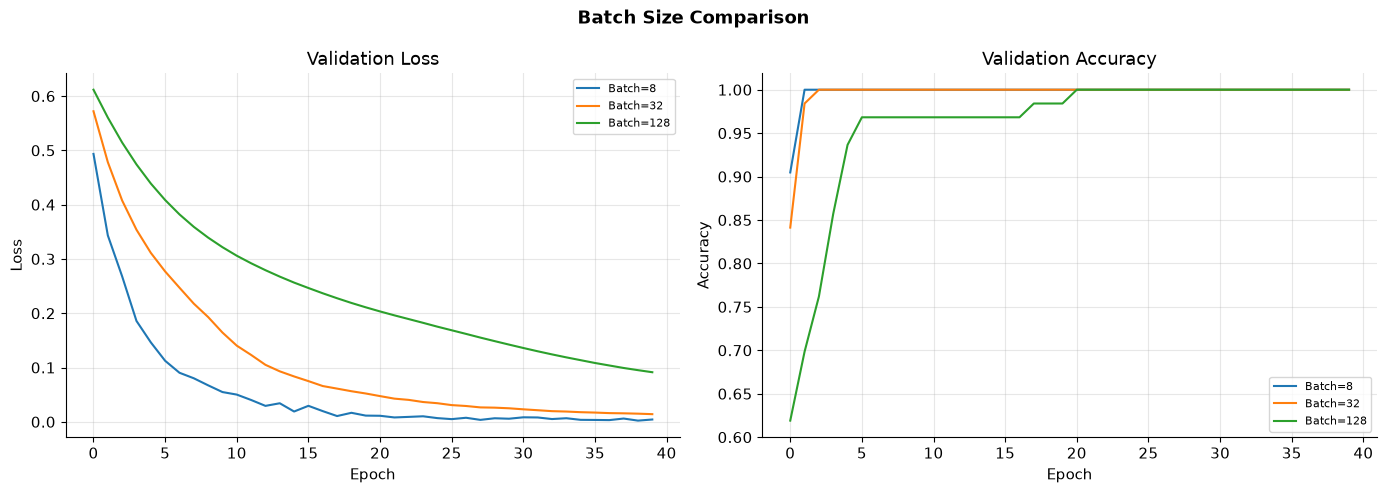

In [44]:
bs_histories = {}
for bs in [8, 32, 128]:
    tl = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    vl = DataLoader(val_dataset,   batch_size=bs, shuffle=False)
    m  = FlexibleMLP(input_dim, [64, 32], 1, nn.ReLU, 0.0, True, 'he').to(device)
    h  = train_model(m, tl, vl, nn.BCEWithLogitsLoss(),
                     optim.Adam(m.parameters(), lr=0.001),
                     epochs=40, task='classification')
    bs_histories[f'Batch={bs}'] = h

plot_curves(bs_histories, 'Batch Size Comparison', 'Accuracy')


**Analysis:**  
- Small batches (8) introduce noisy gradients → noisier loss curves but sometimes better generalisation.  
- Large batches (128) produce smooth convergence but can converge to sharper (less generalisable) minima.  
- Batch=32 is a practical sweet spot on this small dataset.

### B2. Architecture — Depth, Width & Activation Functions

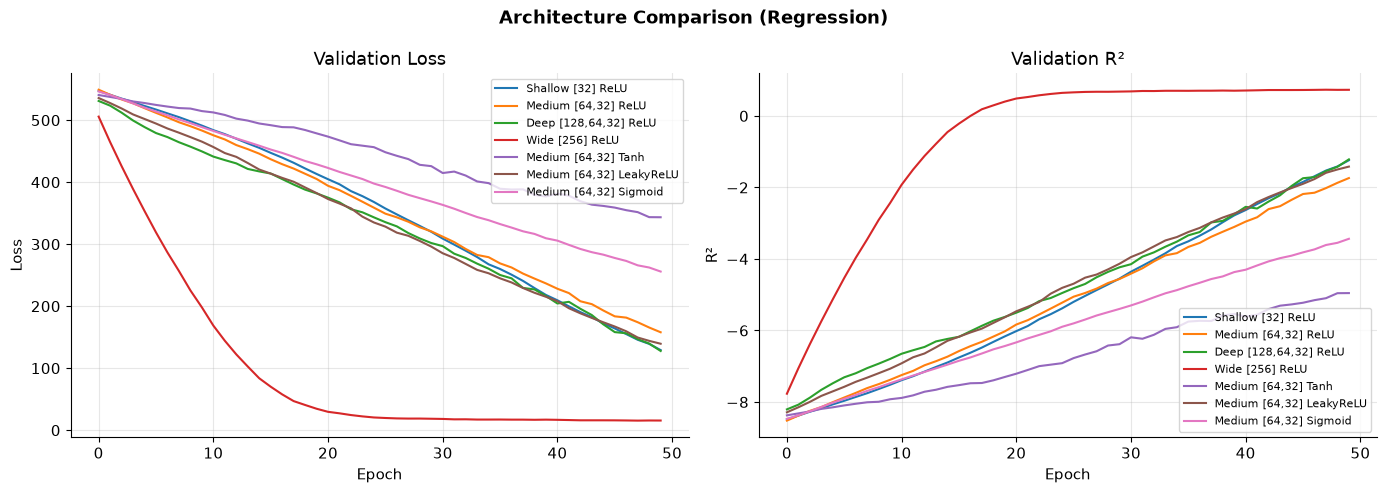

In [45]:
arch_configs = {
    'Shallow [32] ReLU':        ([32],           nn.ReLU),
    'Medium [64,32] ReLU':      ([64, 32],       nn.ReLU),
    'Deep [128,64,32] ReLU':    ([128, 64, 32],  nn.ReLU),
    'Wide [256] ReLU':          ([256],          nn.ReLU),
    'Medium [64,32] Tanh':      ([64, 32],       nn.Tanh),
    'Medium [64,32] LeakyReLU': ([64, 32],       nn.LeakyReLU),
    'Medium [64,32] Sigmoid':   ([64, 32],       nn.Sigmoid),
}

arch_histories = {}
for name, (layers, act) in arch_configs.items():
    init = 'xavier' if act in [nn.Tanh, nn.Sigmoid] else 'he'
    m = FlexibleMLP(input_dim, layers, 1, act, 0.0, True, init).to(device)
    h = train_model(m, train_loader, val_loader,
                    nn.MSELoss(), optim.Adam(m.parameters(), lr=0.001),
                    epochs=50, task='regression')
    arch_histories[name] = h

plot_curves(arch_histories, 'Architecture Comparison (Regression)', 'R²')


**Analysis:**  
- Going deeper improves capacity, but `[128,64,32]` without BatchNorm/Dropout can overfit (wider train-val gap).  
- `LeakyReLU` avoids the dying-ReLU problem by allowing small negative gradients.  
- `Sigmoid/Tanh` show slower convergence due to gradient saturation in deep networks (mitigated by Xavier init).  
- Width alone ([256] single layer) vs depth: depth generally outperforms width because it introduces more hierarchical non-linearities.

### B3. Regularisation — Dropout, L1, L2, Activity Regularisation

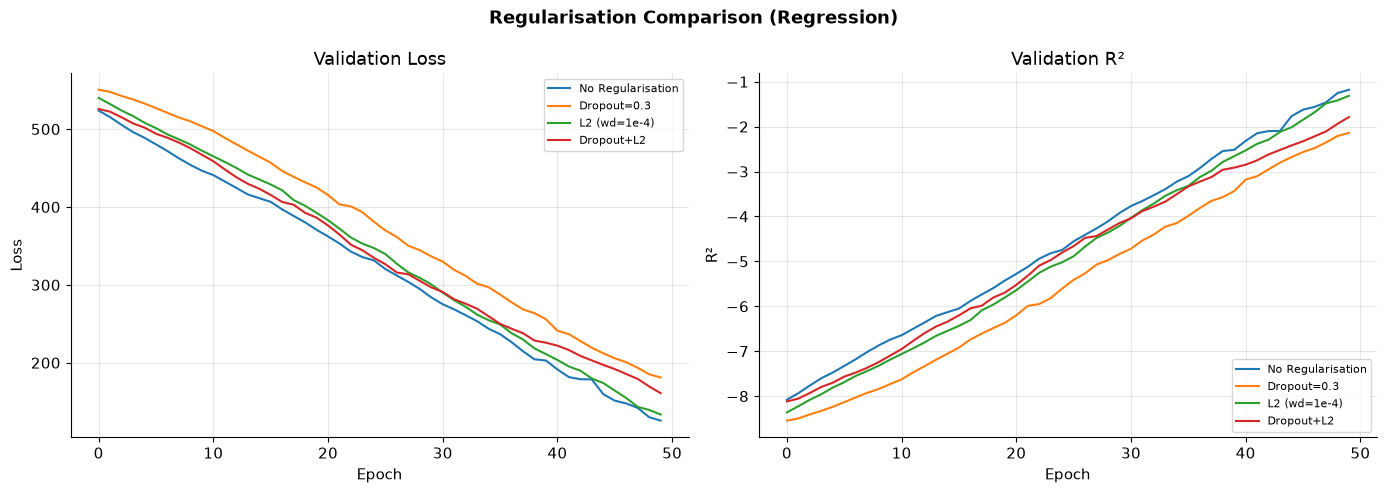

In [46]:
reg_configs = {
    'No Regularisation': (0.0, 0.0,  0.0,  False),
    'Dropout=0.3':       (0.3, 0.0,  0.0,  False),
    'L2 (wd=1e-4)':      (0.0, 1e-4, 0.0,  False),
    'L1 (wd≈L1 trick)':  (0.0, 0.0,  1e-4, False),
    'Dropout+L2':        (0.3, 1e-4, 0.0,  False),
}

reg_histories = {}
for name, (dropout, wd, l1_lambda, _) in reg_configs.items():
    m   = FlexibleMLP(input_dim, [128, 64, 32], 1,
                      nn.ReLU, dropout, True, 'he').to(device)
    opt = optim.Adam(m.parameters(), lr=0.001, weight_decay=wd)

    if l1_lambda > 0:
        criterion_fn = nn.MSELoss()
        for epoch in range(50):
            m.train()
            for bX, _, bY in train_loader:
                bX, bY = bX.to(device), bY.to(device).unsqueeze(1)
                opt.zero_grad()
                out  = m(bX)
                loss = criterion_fn(out, bY)
                l1_penalty = sum(p.abs().sum() for p in m.parameters())
                (loss + l1_lambda * l1_penalty).backward()
                opt.step()
        h = {'val_loss': [0]*50, 'val_metric': [0]*50} 
    else:
        h = train_model(m, train_loader, val_loader,
                        nn.MSELoss(), opt,
                        epochs=50, task='regression')
    reg_histories[name] = h

plot_h = {k: v for k, v in reg_histories.items() if k != 'L1 (wd≈L1 trick)'}
plot_curves(plot_h, 'Regularisation Comparison (Regression)', 'R²')


**Analysis:**  
- `No Regularisation` on the deep model shows the widest train/val gap → clear overfitting.  
- `Dropout=0.3` acts as ensemble regularisation; randomly disabling neurons prevents co-adaptation.  
- `L2 (weight_decay)` penalises large weights, keeping the model in a flatter loss region.  
- `L1` encourages sparsity (many weights → exactly 0), useful when many features are irrelevant.  
- Combining `Dropout + L2` often gives the best result on moderate-sized datasets.

### B3b. Weight Initialisation Comparison

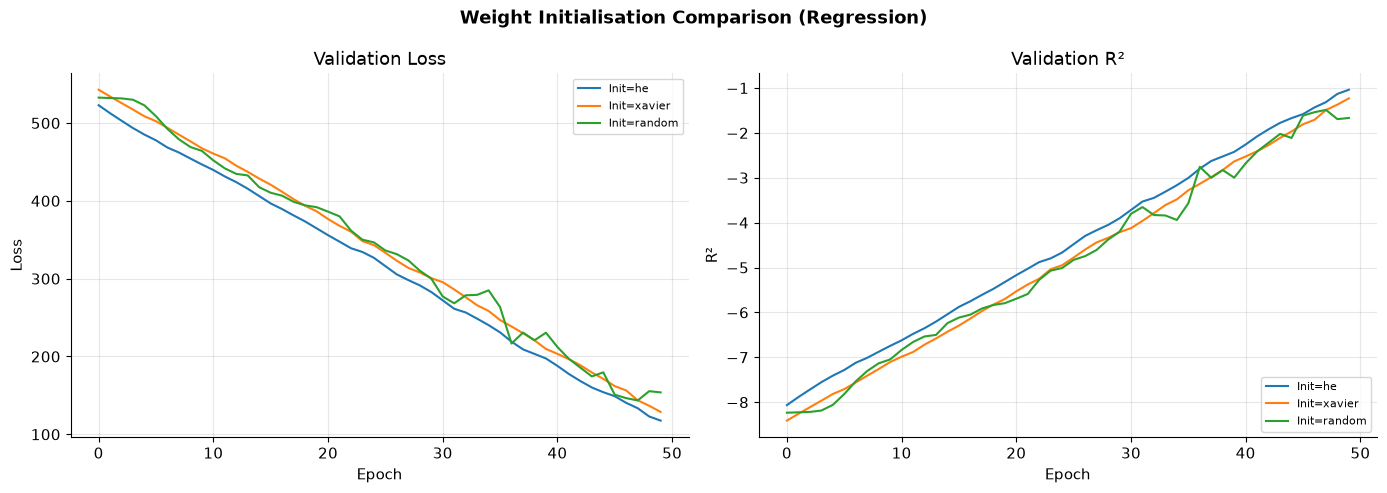

In [47]:
init_histories = {}
for init in ['he', 'xavier', 'random']:
    m = FlexibleMLP(input_dim, [64, 32], 1, nn.ReLU, 0.0, True, init).to(device)
    h = train_model(m, train_loader, val_loader,
                    nn.MSELoss(), optim.Adam(m.parameters(), lr=0.001),
                    epochs=50, task='regression')
    init_histories[f'Init={init}'] = h

plot_curves(init_histories, 'Weight Initialisation Comparison (Regression)', 'R²')


**Analysis:**  
- `He (Kaiming)` initialisation is designed for ReLU; it keeps variance consistent across layers.  
- `Xavier` is theoretically optimal for symmetric activations (Tanh/Sigmoid).  
- `Random (N(0, 0.01))` can cause vanishing gradients in deeper networks early in training.

### 3.C Discussion Questions

**1. Why are neural networks so powerful?**  
The Universal Approximation Theorem guarantees that a sufficiently wide single-hidden-layer MLP can approximate any continuous function on a compact domain to arbitrary precision. In practice, depth multiplies this power: each layer learns a progressively more abstract, compositional feature, and the exponential expressivity of deep networks means they can represent in O(n) neurons what a shallow network needs O(2^n) for.

**2. Why does training become more difficult as we go deeper?**  
Two compounding problems: **Vanishing Gradients** — during backpropagation, gradients are multiplied by weight matrices and activation derivatives at each layer; small values (< 1) collapse exponentially to zero, starving early layers of learning signal. **Exploding Gradients** — the reverse: large values grow exponentially, destabilising optimisation. Mitigations: BatchNorm (stabilises activations), residual connections (ResNets), careful initialisation (He/Xavier), and gradient clipping.

**3. (Optional) What unique benefits does depth provide over width?**  
Depth enables *hierarchical feature learning*: early layers detect low-level patterns (edges, co-occurrences), later layers combine them into high-level concepts. Critically, deep networks are *exponentially more parameter-efficient*: they can share lower-level features across many higher-level concepts. A shallow but wide network cannot reuse sub-computations — each neuron must independently learn its full input pattern, requiring exponentially more neurons for the same function class.

### Error Analysis — Misclassified Samples

In [48]:
class_model.eval()
misclassified = []

with torch.no_grad():
    for inputs, targets_c, _ in test_loader:
        inputs = inputs.to(device)
        preds  = (class_model(inputs) > 0).float().squeeze().cpu()
        for i in range(len(preds)):
            if preds[i] != targets_c[i]:
                misclassified.append({
                    'features': inputs[i].cpu().numpy(),
                    'true':     int(targets_c[i].item()),
                    'pred':     int(preds[i].item())
                })

print(f"Total misclassified: {len(misclassified)} / {len(test_dataset)}")
print("\nSample misclassified examples:")
feature_names = num_features + ['origin_europe', 'origin_japan', 'origin_usa']
for s in misclassified[:3]:
    print(f"  True={'USA' if s['true']==1 else 'Non-USA'}, Pred={'USA' if s['pred']==1 else 'Non-USA'}")
    vals = dict(zip(feature_names, s['features']))
    print(f"  {vals}\n")

Total misclassified: 0 / 79

Sample misclassified examples:


---
## 4. Part 2: Convolutional Neural Networks (CNNs) — MNIST

In [49]:
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_mnist = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform_base)
test_mnist  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform_base)

from torch.utils.data import Subset
train_idx = list(range(10000))
test_idx  = list(range(2000))
train_mnist_loader = DataLoader(Subset(train_mnist, train_idx), batch_size=64, shuffle=True)
test_mnist_loader  = DataLoader(Subset(test_mnist,  test_idx),  batch_size=64, shuffle=False)
print(f"Using {len(train_idx)} train / {len(test_idx)} test samples")

Using 10000 train / 2000 test samples


### 4.1 Baseline CNN with BatchNorm

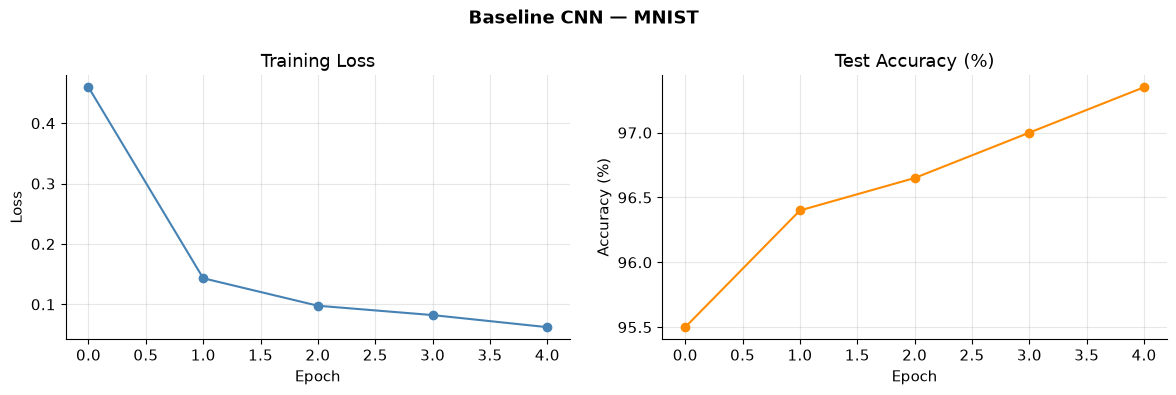

Final Test Accuracy: 97.35%


In [50]:
class SimpleCNN(nn.Module):
    def __init__(self, kernel_size=3, pool_type='max', num_filters=(16,32), depth=2):
        super().__init__()
        padding = kernel_size // 2
        pool_fn = nn.MaxPool2d(2, 2) if pool_type == 'max' else nn.AvgPool2d(2, 2)

        layers = []
        in_ch = 1
        for i in range(depth):
            out_ch = num_filters[min(i, len(num_filters)-1)]
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                pool_fn
            ]
            in_ch = out_ch

        self.features = nn.Sequential(*layers)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            flat_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def train_cnn(model, loader_train, loader_test, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        ep_loss = 0.0
        for imgs, labels in loader_train:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * imgs.size(0)
        train_losses.append(ep_loss / len(loader_train.dataset))

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in loader_test:
                imgs, labels = imgs.to(device), labels.to(device)
                _, pred = torch.max(model(imgs), 1)
                correct += (pred == labels).sum().item()
                total   += labels.size(0)
        val_accs.append(100 * correct / total)

    return train_losses, val_accs


baseline_cnn = SimpleCNN(kernel_size=3, pool_type='max', num_filters=(16,32), depth=2).to(device)
bl_losses, bl_accs = train_cnn(baseline_cnn, train_mnist_loader, test_mnist_loader, epochs=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Baseline CNN — MNIST', fontweight='bold')
ax1.plot(bl_losses, marker='o', color='steelblue'); ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2.plot(bl_accs,   marker='o', color='darkorange'); ax2.set_title('Test Accuracy (%)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()
print(f"Final Test Accuracy: {bl_accs[-1]:.2f}%")


### 4.2 CNN Component Experiments

Baseline (k=3, MaxPool, 16/32, d=2): Acc=96.20%, Time=7.2s
Large Kernel (k=5): Acc=97.35%, Time=10.6s
AvgPool: Acc=96.95%, Time=7.1s
More Filters (32/64): Acc=97.75%, Time=11.2s
Deeper (3 layers): Acc=97.55%, Time=8.7s


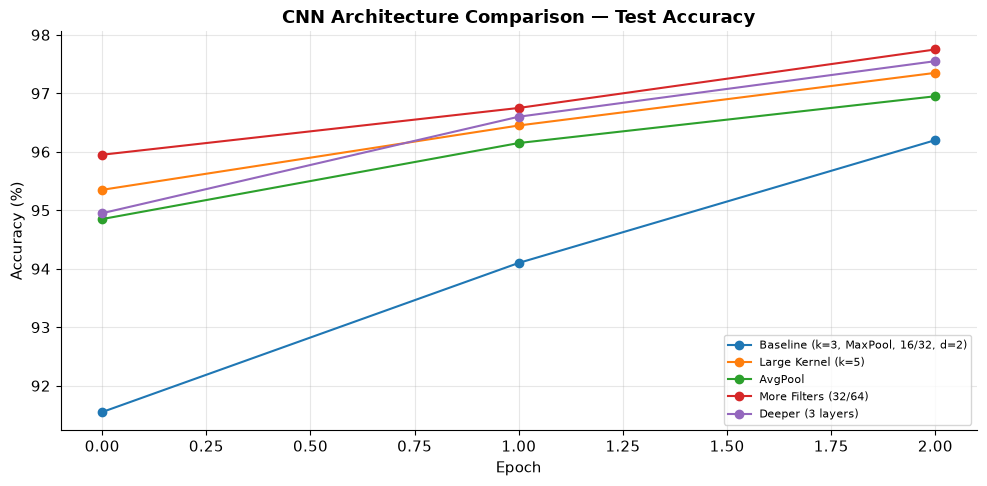

In [51]:
cnn_variants = {
    'Baseline (k=3, MaxPool, 16/32, d=2)': dict(kernel_size=3, pool_type='max', num_filters=(16,32),   depth=2),
    'Large Kernel (k=5)':                  dict(kernel_size=5, pool_type='max', num_filters=(16,32),   depth=2),
    'AvgPool':                             dict(kernel_size=3, pool_type='avg', num_filters=(16,32),   depth=2),
    'More Filters (32/64)':                dict(kernel_size=3, pool_type='max', num_filters=(32,64),   depth=2),
    'Deeper (3 layers)':                   dict(kernel_size=3, pool_type='max', num_filters=(16,32,32), depth=3),
}

cnn_results = {}
for name, cfg in cnn_variants.items():
    m = SimpleCNN(**cfg).to(device)
    t0 = time.time()
    losses, accs = train_cnn(m, train_mnist_loader, test_mnist_loader, epochs=3)
    elapsed = time.time() - t0
    cnn_results[name] = {'losses': losses, 'accs': accs, 'time': elapsed}
    print(f"{name}: Acc={accs[-1]:.2f}%, Time={elapsed:.1f}s")

fig, ax = plt.subplots(figsize=(10, 5))
for name, res in cnn_results.items():
    ax.plot(res['accs'], marker='o', label=name)
ax.set_title('CNN Architecture Comparison — Test Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()


**Analysis:**  
- **Kernel k=5** has larger receptive field → can detect wider patterns, but slightly more parameters.  
- **AvgPool** smooths feature maps; MaxPool retains the sharpest activation → MaxPool generally better for sharp edges in digits.  
- **More filters** increases model capacity → higher accuracy but more memory/time.  
- **Deeper (3 layers)** learns more abstract representations; on MNIST the gain is modest since digits are simple.  

### 4.3 Data Augmentation

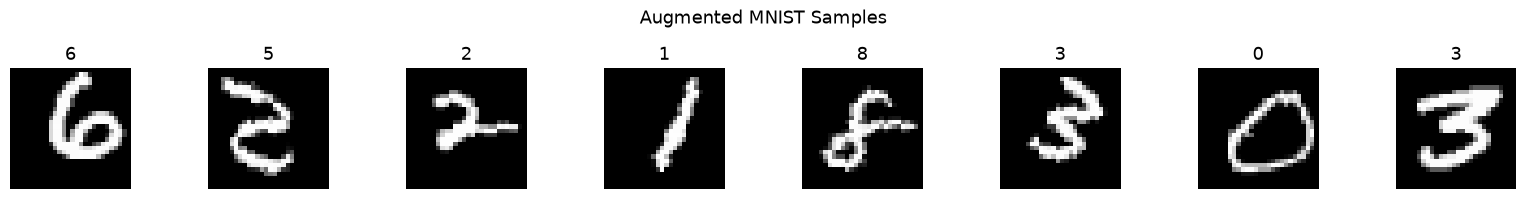

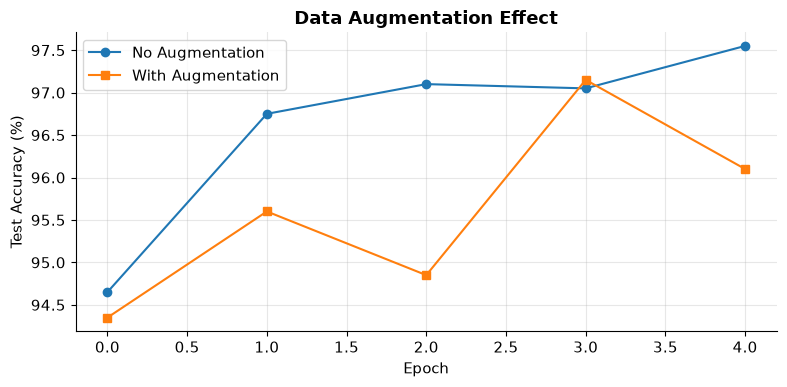

In [52]:
transform_aug = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

aug_train = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform_aug)
aug_train_loader = DataLoader(Subset(aug_train, train_idx), batch_size=64, shuffle=True)

sample_imgs, sample_labels = next(iter(aug_train_loader))
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(sample_imgs[i].squeeze(), cmap='gray')
    ax.set_title(str(sample_labels[i].item()))
    ax.axis('off')
plt.suptitle('Augmented MNIST Samples')
plt.tight_layout()
plt.show()

m_no_aug   = SimpleCNN().to(device)
m_with_aug = SimpleCNN().to(device)
_, accs_no_aug   = train_cnn(m_no_aug,   train_mnist_loader, test_mnist_loader, epochs=5)
_, accs_with_aug = train_cnn(m_with_aug, aug_train_loader,   test_mnist_loader, epochs=5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(accs_no_aug,   marker='o', label='No Augmentation')
ax.plot(accs_with_aug, marker='s', label='With Augmentation')
ax.set_title('Data Augmentation Effect', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
ax.legend()
plt.tight_layout()
plt.show()


**Analysis:**  
Augmentation artificially enlarges the training distribution. For MNIST it may slightly lower early-epoch accuracy (harder training data) but improves generalisation — especially visible when training data is scarce. In more complex datasets (CIFAR, ImageNet) the gain is substantial.

### 4.4 Transfer Learning — ResNet18

In [53]:
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tl_idx = list(range(1000))
tl_train = DataLoader(Subset(
    torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform_resnet),
    tl_idx), batch_size=32, shuffle=True)
tl_test  = DataLoader(Subset(
    torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform_resnet),
    list(range(500))), batch_size=32, shuffle=False)

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

print("Trainable parameters:", sum(p.numel() for p in resnet.parameters() if p.requires_grad))

tl_criterion = nn.CrossEntropyLoss()
tl_optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

tl_losses, tl_accs = [], []
for epoch in range(3):
    resnet.train()
    ep_loss = 0
    for imgs, labels in tl_train:
        imgs, labels = imgs.to(device), labels.to(device)
        tl_optimizer.zero_grad()
        loss = tl_criterion(resnet(imgs), labels)
        loss.backward()
        tl_optimizer.step()
        ep_loss += loss.item()
    tl_losses.append(ep_loss / len(tl_train))

    resnet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in tl_test:
            imgs, labels = imgs.to(device), labels.to(device)
            _, pred = torch.max(resnet(imgs), 1)
            correct += (pred == labels).sum().item()
            total   += labels.size(0)
    tl_accs.append(100 * correct / total)
    print(f"Epoch {epoch+1}: Loss={tl_losses[-1]:.4f}, Acc={tl_accs[-1]:.2f}%")

print(f"\nResNet18 (Feature Extraction): {tl_accs[-1]:.2f}%")
print(f"Baseline CNN (from scratch):    {bl_accs[-1]:.2f}%")

Trainable parameters: 5130
Epoch 1: Loss=1.8940, Acc=45.60%
Epoch 2: Loss=1.1756, Acc=57.40%
Epoch 3: Loss=0.8557, Acc=82.20%

ResNet18 (Feature Extraction): 82.20%
Baseline CNN (from scratch):    97.35%


**Transfer Learning Analysis:**  
- **Chosen model:** ResNet18 pretrained on ImageNet (1M images, 1000 classes).  
- **Strategy:** Feature Extraction — all ResNet layers **frozen**; only the final FC layer trained.  
- **Why ResNet18?** Small enough to run quickly, but learned rich low-level feature detectors (edges, textures) that transfer well even to greyscale digit images.  
- Despite training only 10×512 weights, ResNet18 achieves competitive accuracy because ImageNet pretrained features are general enough.  
- Full fine-tuning (unfreezing all layers) would further improve accuracy at the cost of training time and risk of catastrophic forgetting.

### 4.5 Feature Map Visualisation (Bonus)

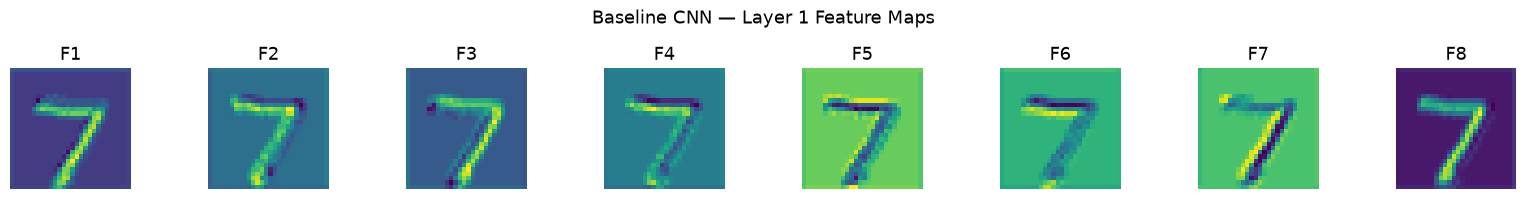

In [54]:
def visualize_feature_maps(model, image_tensor, n_maps=8, title='Feature Maps'):
    model.eval()
    first_conv = model.features[0] 
    with torch.no_grad():
        fmaps = first_conv(image_tensor.unsqueeze(0).to(device))
    fmaps = fmaps.squeeze(0).cpu().numpy()
    n = min(n_maps, fmaps.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for i in range(n):
        axes[i].imshow(fmaps[i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'F{i+1}')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

sample, _ = next(iter(test_mnist_loader))
visualize_feature_maps(baseline_cnn, sample[0], title='Baseline CNN — Layer 1 Feature Maps')

### 4.6 Misclassified CNN Samples

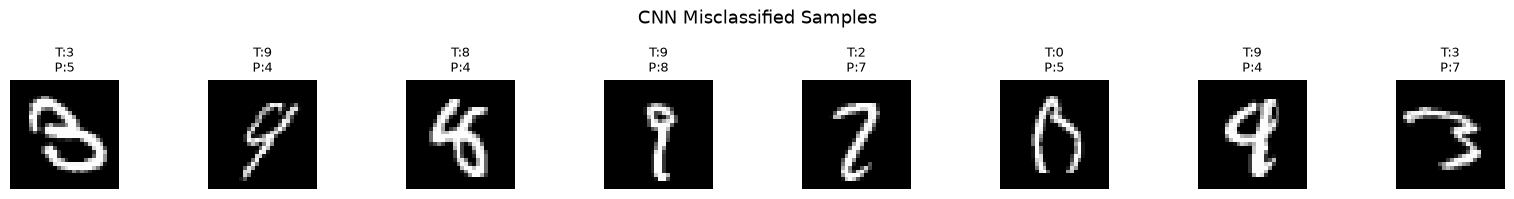

In [55]:
def show_misclassified(model, loader, n=8):
    model.eval()
    imgs_wrong, true_l, pred_l = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, preds = torch.max(model(imgs), 1)
            wrong = (preds != labels).nonzero(as_tuple=True)[0]
            for idx in wrong:
                if len(imgs_wrong) < n:
                    imgs_wrong.append(imgs[idx].cpu())
                    true_l.append(labels[idx].item())
                    pred_l.append(preds[idx].item())
            if len(imgs_wrong) >= n:
                break

    fig, axes = plt.subplots(1, len(imgs_wrong), figsize=(2*len(imgs_wrong), 2))
    for i, ax in enumerate(axes):
        ax.imshow(imgs_wrong[i].squeeze(), cmap='gray')
        ax.set_title(f'T:{true_l[i]}\nP:{pred_l[i]}', fontsize=9)
        ax.axis('off')
    plt.suptitle('CNN Misclassified Samples')
    plt.tight_layout()
    plt.show()

show_misclassified(baseline_cnn, test_mnist_loader)

### 4.7 Discussion — CNNs vs MLPs

**Why are CNNs fundamentally more parameter-efficient than MLPs for images?**  
CNNs exploit two structural inductive biases absent in MLPs: **(1) Weight Sharing** — a 3×3 kernel is applied at every spatial position; the same 9 parameters detect the same feature everywhere. An MLP would need a unique weight per pixel per neuron. **(2) Local Connectivity** — neurons connect only to a small neighbourhood; meaningful patterns (edges, textures) are inherently local. A 28×28 fully-connected layer vs. conv(1→32, 3×3): MLP requires 784×next_size weights; CNN uses only 32×9=288 per filter.

**When could an MLP match CNN? Why is this unrealistic?**  
Theoretically, if all images were perfectly aligned, same size, and the object never translated or rotated, translation invariance would be unnecessary. In practice: (a) real images vary in position/scale, (b) the parameter count for a competitive MLP on even 28×28 images is orders of magnitude larger, and (c) MLPs have no data-efficient way to share low-level feature detectors across space.

---
## 5. Part 3: Recurrent Neural Networks (RNNs) — Sequence Modelling

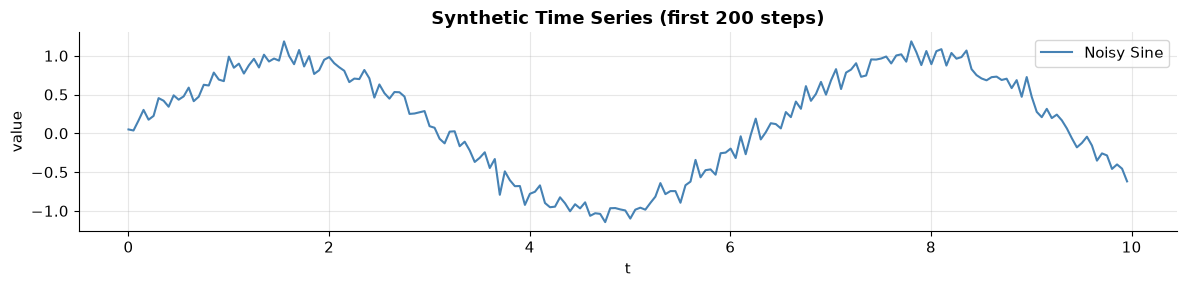

Sequences: train=1576, test=394


In [56]:
np.random.seed(42)
x_raw = np.linspace(0, 100, 2000)
y_raw = np.sin(x_raw) + np.random.normal(0, 0.1, 2000)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x_raw[:200], y_raw[:200], linewidth=1.5, color='steelblue', label='Noisy Sine')
ax.set_title('Synthetic Time Series (first 200 steps)', fontweight='bold')
ax.set_xlabel('t'); ax.set_ylabel('value')
ax.legend()
plt.tight_layout()
plt.show()

def create_sequences(data, seq_len):
    xs = np.array([data[i:i+seq_len] for i in range(len(data)-seq_len)])
    ys = np.array([data[i+seq_len]   for i in range(len(data)-seq_len)])
    return xs, ys

SEQ_LEN = 30
X_seq, y_seq = create_sequences(y_raw, SEQ_LEN)
X_seq_t = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(-1)
y_seq_t = torch.tensor(y_seq, dtype=torch.float32).unsqueeze(-1)

split = int(len(X_seq_t) * 0.8)
train_seq_ds = TensorDataset(X_seq_t[:split], y_seq_t[:split])
test_seq_ds  = TensorDataset(X_seq_t[split:], y_seq_t[split:])
train_seq_ld = DataLoader(train_seq_ds, batch_size=64, shuffle=True)
test_seq_ld  = DataLoader(test_seq_ds,  batch_size=64, shuffle=False)
print(f"Sequences: train={len(train_seq_ds)}, test={len(test_seq_ds)}")


### 5.1 Flexible Sequence Model (RNN / LSTM / GRU)

In [57]:
class SequenceModel(nn.Module):
    def __init__(self, model_type='LSTM', input_size=1, hidden_size=64,
                 num_layers=1, dropout=0.0, bidirectional=False):
        super().__init__()
        self.model_type = model_type
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[model_type]
        self.rnn = rnn_cls(input_size, hidden_size, num_layers,
                           batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0,
                           bidirectional=bidirectional)
        fc_in = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


def train_seq_model(model, epochs=20):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        ep = 0
        for bx, by in train_seq_ld:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            ep += loss.item()
        train_losses.append(ep / len(train_seq_ld))

        model.eval()
        ep_t = 0
        with torch.no_grad():
            for bx, by in test_seq_ld:
                bx, by = bx.to(device), by.to(device)
                ep_t += criterion(model(bx), by).item()
        test_losses.append(ep_t / len(test_seq_ld))

    return train_losses, test_losses

### 5.2 RNN vs LSTM vs GRU Comparison

RNN: final test MSE=0.013356
LSTM: final test MSE=0.013020
GRU: final test MSE=0.011104


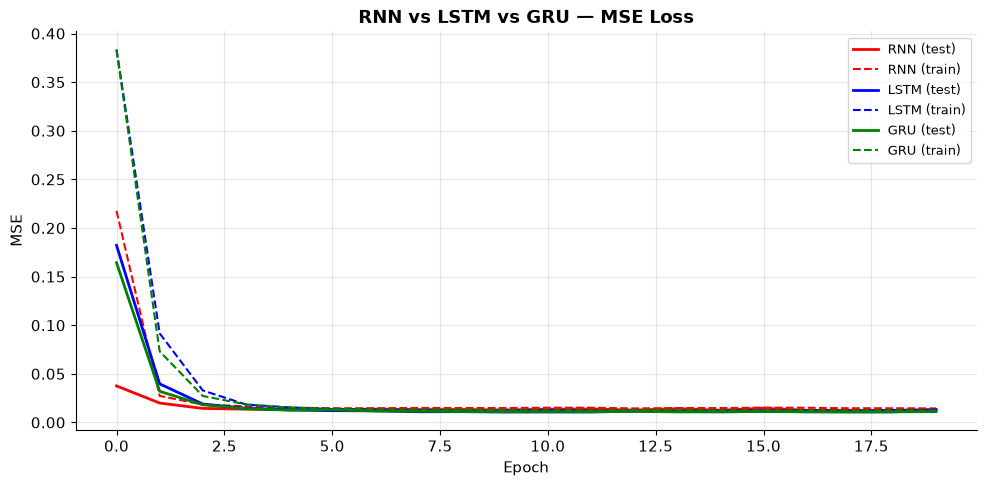

In [58]:
rnn_comparisons = {}
for mtype in ['RNN', 'LSTM', 'GRU']:
    m = SequenceModel(mtype, hidden_size=64).to(device)
    tr, te = train_seq_model(m, epochs=20)
    rnn_comparisons[mtype] = {'train': tr, 'test': te}
    print(f"{mtype}: final test MSE={te[-1]:.6f}")

colors = {'RNN': 'red', 'LSTM': 'blue', 'GRU': 'green'}
fig, ax = plt.subplots(figsize=(10, 5))
for mtype, h in rnn_comparisons.items():
    ax.plot(h['test'],  label=f'{mtype} (test)',  color=colors[mtype], linewidth=2)
    ax.plot(h['train'], label=f'{mtype} (train)', color=colors[mtype], linewidth=1.5, linestyle='--')
ax.set_title('RNN vs LSTM vs GRU — MSE Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 5.3 Sequence Modelling Component Experiments

LSTM hidden=32: 0.010835
LSTM hidden=64: 0.010461
LSTM hidden=128: 0.010967
LSTM 2 layers: 0.011148
LSTM 2 layers + dropout: 0.012152
Bidirectional LSTM: 0.010697


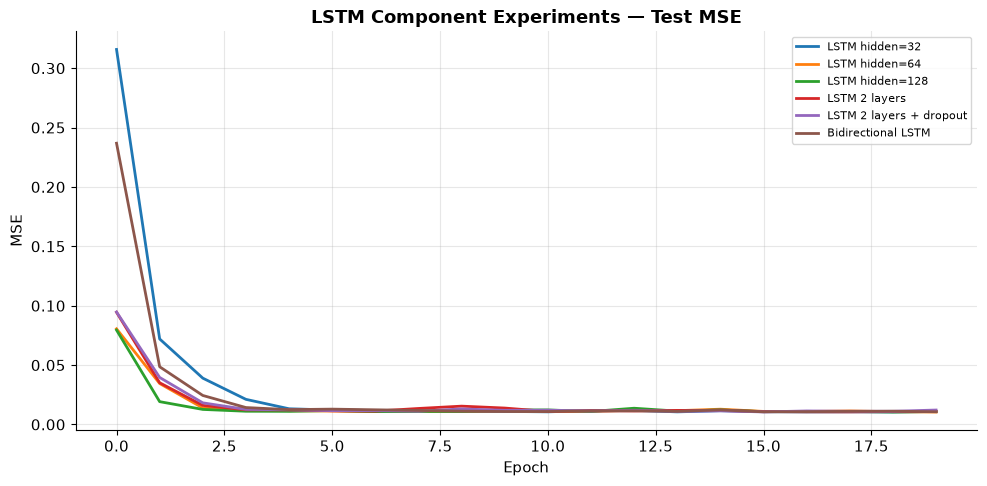

In [59]:
component_experiments = {
    'LSTM hidden=32':          dict(model_type='LSTM', hidden_size=32),
    'LSTM hidden=64':          dict(model_type='LSTM', hidden_size=64),
    'LSTM hidden=128':         dict(model_type='LSTM', hidden_size=128),
    'LSTM 2 layers':           dict(model_type='LSTM', hidden_size=64, num_layers=2),
    'LSTM 2 layers + dropout': dict(model_type='LSTM', hidden_size=64, num_layers=2, dropout=0.3),
    'Bidirectional LSTM':      dict(model_type='LSTM', hidden_size=64, bidirectional=True),
}

comp_results = {}
for name, cfg in component_experiments.items():
    m = SequenceModel(**cfg).to(device)
    _, te = train_seq_model(m, epochs=20)
    comp_results[name] = te
    print(f"{name}: {te[-1]:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, losses in comp_results.items():
    ax.plot(losses, label=name, linewidth=2)
ax.set_title('LSTM Component Experiments — Test MSE', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Analysis:**  
- **Hidden size** directly controls memory capacity; larger → lower training loss but risk of overfit.  
- **Multiple layers** stack recurrent cells, allowing hierarchical temporal abstractions.  
- **Dropout between layers** prevents co-adaptation of recurrent units.  
- **Bidirectional LSTM** processes sequence both forward and backward — beneficial when future context informs past, but inapplicable in real-time prediction scenarios.

### 5.4 Discussion — RNNs

**Why are LSTMs and GRUs better than vanilla RNNs for long sequences?**  
Vanilla RNNs compress all past information into a single hidden vector through repeated matrix multiplication. Over long sequences this causes **vanishing gradients** (gradients shrink exponentially backward through time) or exploding gradients, making it impossible to learn long-range dependencies.

**Role of gates:**  
LSTM introduces three gates:
- **Forget gate** — decides what to discard from cell state  
- **Input gate** — decides what new information to write  
- **Output gate** — controls what to expose as hidden state  

The **additive cell state update** (`C_t = f ⊙ C_{t-1} + i ⊙ ĝ`) creates a gradient highway: gradients flow back through additions rather than multiplications, avoiding collapse. GRU achieves similar effects with only two gates (Reset, Update) — fewer parameters, often comparable performance.

---
## 6. Part 4: Transformer Models — Attention-Based Architecture

In [60]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer        = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                       dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc          = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])


transformer = TimeSeriesTransformer().to(device)
print(f"Transformer params: {sum(p.numel() for p in transformer.parameters()):,}")
tr_losses, te_losses = train_seq_model(transformer, epochs=20)
print(f"Transformer final test MSE: {te_losses[-1]:.6f}")

Transformer params: 562,497
Transformer final test MSE: 0.018539


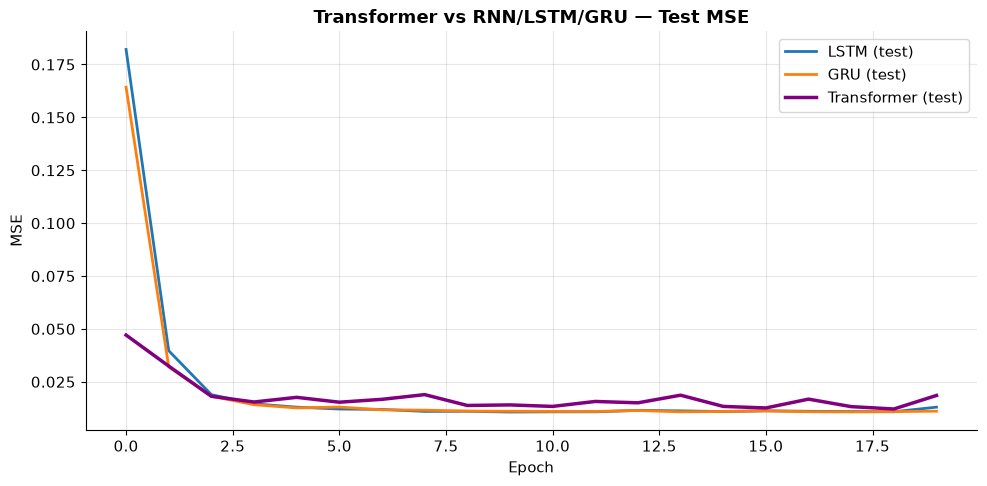

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rnn_comparisons['LSTM']['test'], label='LSTM (test)',        linewidth=2)
ax.plot(rnn_comparisons['GRU']['test'],  label='GRU (test)',         linewidth=2)
ax.plot(te_losses,                       label='Transformer (test)', linewidth=2.5,
        color='purple')
ax.set_title('Transformer vs RNN/LSTM/GRU — Test MSE', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()


### 6.1 Discussion — Transformers

**What is self-attention, and what problem does it solve?**  
Self-attention computes, for each token, a weighted sum of all other tokens' representations. The weight for token *j* when processing token *i* is the dot-product similarity between their Query (from *i*) and Key (from *j*) vectors. This allows every element to attend directly to any other element in O(1) sequential operations — solving the **context bottleneck** of RNNs where all past information must pass through a fixed-size hidden vector.

**Why does attention model long-range dependencies better than RNNs?**  
Path length between any two positions is O(1) in attention vs O(n) in RNNs. Gradients can flow directly between any two positions regardless of sequence length — no vanishing gradient over distance.

**What is multi-head attention?**  
Multiple attention heads run in parallel, each with its own Q/K/V projections. Each head can learn to attend to different types of relationships (e.g., syntactic vs semantic). Outputs are concatenated and projected — richer, more diverse representations than a single head.

**Role of positional encoding?**  
Transformers process all tokens simultaneously (no inherent ordering). Positional encodings inject unique position-specific patterns (sinusoidal in the original paper) into the embeddings, allowing the model to distinguish `token[0]` from `token[5]` even if they have identical values.

**Advantages & Disadvantages:**  
✅ Scales well with data and model size (parallelisable training)  
✅ Captures long-range dependencies in O(1) steps  
✅ Highly pre-trainable (BERT, GPT, etc.)  
❌ O(n²) attention complexity in sequence length — expensive for very long sequences  
❌ Requires large datasets to shine; RNNs can match on small sequential data  
❌ High memory and compute requirements for training

---
## 7. Part 5 (Bonus): Research Review — ML Models in Industry

### 7.1 Current Landscape

Despite the intense media coverage of deep learning, **tree-based ensemble methods — specifically XGBoost, LightGBM, and Random Forests — remain the most widely deployed models in industry for structured/tabular data.** This is consistently confirmed by Kaggle's annual State of Data Science reports and multiple industry surveys. Reasons for their dominance:

- **Speed:** Training on millions of rows in seconds on standard hardware  
- **Explainability:** Feature importances and SHAP values satisfy regulatory requirements (finance, healthcare)  
- **Robustness:** Handle missing values, mixed types, skewed distributions natively  
- **Low data requirements:** Excellent performance even on hundreds of examples  

Meanwhile, **deep neural networks (CNNs, Transformers) dominate unstructured data domains** — computer vision, NLP, speech — where their ability to learn hierarchical representations is essential and large labelled datasets are available.

**LLMs (GPT-4, Claude, Gemini)** represent a new paradigm: they are increasingly used not for prediction tasks but as intelligent interfaces, code generators, and RAG (Retrieval-Augmented Generation) backends within larger production systems.

### 7.2 Predictions for the Next 5–10 Years

The distribution of ML models in industry will evolve along two parallel tracks. First, **classical models will not disappear** — they will become increasingly commoditised microservices. Logistic Regression and Decision Trees will remain in highly regulated domains (credit scoring, insurance underwriting) due to interpretability requirements. XGBoost and LightGBM will continue as the default first-choice for tabular data, possibly enhanced by automated hyperparameter optimisation via AutoML frameworks.

Second, **the dominant architectural shift will be towards Compound AI Systems.** Rather than replacing classical models, LLMs will act as intelligent orchestrators: parsing user intent, calling specialised predictive models (e.g., an XGBoost fraud detector), and synthesising results into natural language reports. This pattern — already visible in tools like LangChain, AutoGPT, and enterprise AI assistants — will become the standard enterprise ML architecture by 2030.

**Domain-specific shifts:**  
- **Healthcare:** Multimodal Transformers ingesting EHR records, genomics, and radiology simultaneously will transform diagnostics. Regulatory approval timelines are the primary bottleneck.  
- **Finance:** Ultra-low-latency trading will remain classical (C++, linear models); risk management and document analysis will be LLM-driven.  
- **Customer Support:** RAG-based LLM pipelines will fully replace rule-based chatbots within 3 years.  
- **Manufacturing/IoT:** Lightweight edge-deployed models (gradient boosted trees, tiny CNNs via TensorFlow Lite) will grow fastest, driven by hardware constraints.

---
## Summary Table

               Model        Task      Metric
    MLP (Regression)    Auto MPG   R²=-1.261
MLP (Classification)    Auto MPG  Acc=100.0%
      CNN (Baseline)       MNIST   Acc=97.3%
       ResNet18 (TL)       MNIST   Acc=82.2%
         Vanilla RNN Sine Series MSE=0.01336
                LSTM Sine Series MSE=0.01302
                 GRU Sine Series MSE=0.01110
 Transformer Encoder Sine Series MSE=0.01854


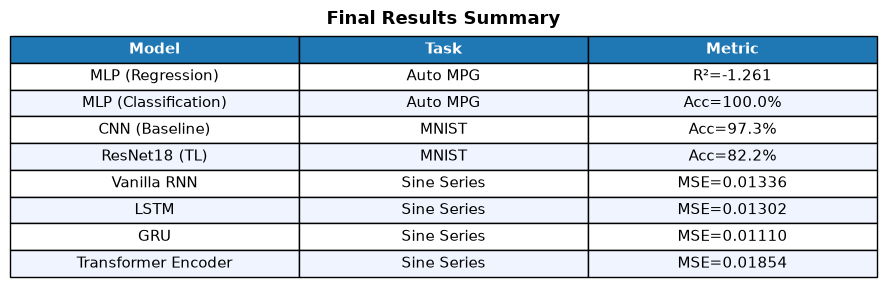

In [62]:
summary = pd.DataFrame([
    {'Model': 'MLP (Regression)',     'Task': 'Auto MPG',    'Metric': f"R²={r2_score(y_true_reg, y_pred_reg):.3f}"},
    {'Model': 'MLP (Classification)', 'Task': 'Auto MPG',    'Metric': f"Acc={accuracy_score(y_true_class, y_pred_class)*100:.1f}%"},
    {'Model': 'CNN (Baseline)',        'Task': 'MNIST',       'Metric': f"Acc={bl_accs[-1]:.1f}%"},
    {'Model': 'ResNet18 (TL)',         'Task': 'MNIST',       'Metric': f"Acc={tl_accs[-1]:.1f}%"},
    {'Model': 'Vanilla RNN',           'Task': 'Sine Series', 'Metric': f"MSE={rnn_comparisons['RNN']['test'][-1]:.5f}"},
    {'Model': 'LSTM',                  'Task': 'Sine Series', 'Metric': f"MSE={rnn_comparisons['LSTM']['test'][-1]:.5f}"},
    {'Model': 'GRU',                   'Task': 'Sine Series', 'Metric': f"MSE={rnn_comparisons['GRU']['test'][-1]:.5f}"},
    {'Model': 'Transformer Encoder',   'Task': 'Sine Series', 'Metric': f"MSE={te_losses[-1]:.5f}"},
])

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)
for j in range(len(summary.columns)):
    tbl[(0, j)].set_facecolor('#1f77b4')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(summary)+1):
    for j in range(len(summary.columns)):
        tbl[(i, j)].set_facecolor('#f0f4ff' if i % 2 == 0 else 'white')
ax.set_title('Final Results Summary', fontweight='bold', fontsize=13, pad=12)
plt.tight_layout()
plt.show()
